In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from anonymeter.evaluators import SinglingOutEvaluator
from anonymeter.evaluators import LinkabilityEvaluator
from anonymeter.evaluators import InferenceEvaluator

# # create a file handler
# file_handler = logging.FileHandler("anonymeter.log")

# # set the logging level for the file handler
# file_handler.setLevel(logging.DEBUG)

# # add the file handler to the logger
# logger = logging.getLogger("anonymeter")
# logger.addHandler(file_handler)
# logger.setLevel(logging.DEBUG)

In [2]:
ori = pd.read_csv("ori_214000_float.csv")
syn = pd.read_csv("ori_214000_fix_dp_v3_float.csv")
control = pd.read_csv("control_float.csv")

In [3]:
evaluator = SinglingOutEvaluator(ori=ori, 
                                 syn=syn, 
                                 control=control,
                                 n_attacks=500)

try:
    evaluator.evaluate(mode='multivariate') # mode = "univariate" or "multivariate"
    risk = evaluator.risk()
    print(risk)

except RuntimeError as ex: 
    print(f"Singling out evaluation failed with {ex}. Please re-run this cell."
          "For more stable results increase `n_attacks`. Note that this will "
          "make the evaluation slower.")

PrivacyRisk(value=0.12199868607556028, ci=(0.08970660016532159, 0.15429077198579896))


In [4]:
evaluator.queries()[:3]

["id<= 140330 & education== 'Doctorate' & occupation== 'Admin-hospitality'",
 "income>= 135145 & occupation== 'Handers-cleaners' & id<= 58062",
 "id<= 207973 & occupation== 'Maj-gen-exec-military' & education== 'Doctorate'"]

In [5]:
res = evaluator.results()

print("Successs rate of main attack:", res.attack_rate)
print("Successs rate of baseline attack:", res.baseline_rate)
print("Successs rate of control attack:", res.control_rate)

Successs rate of main attack: SuccessRate(value=0.13877525992800502, error=0.030059816520767803)
Successs rate of baseline attack: SuccessRate(value=0.08717172563200573, error=0.02442758882817536)
Successs rate of control attack: SuccessRate(value=0.019107686499303486, error=0.01137336472653644)


In [11]:
aux_cols = [
    ['id','age' , 'education', 'occupation'],
    ['income', 'mobility','health','life_quality']
]

evaluator = LinkabilityEvaluator(ori=ori, 
                                 syn=syn, 
                                 control=control,
                                 n_attacks=5000,
                                 aux_cols=aux_cols,
                                 n_neighbors=10)

evaluator.evaluate(n_jobs=-1)  # n_jobs follow joblib convention. -1 = all cores, -2 = all execept one
evaluator.risk()

PrivacyRisk(value=0.00020000317087385736, ci=(0.0, 0.0012309639762411566))

In [12]:
res = evaluator.results()

print("Successs rate of main attack:", res.attack_rate)
print("Successs rate of baseline attack:", res.baseline_rate)
print("Successs rate of control attack:", res.control_rate)

Successs rate of main attack: SuccessRate(value=0.0009833903513615278, error=0.0007793156971671813)
Successs rate of baseline attack: SuccessRate(value=0.0007835438917505393, error=0.0006738426096729043)
Successs rate of control attack: SuccessRate(value=0.0007835438917505393, error=0.0006738426096729043)


In [13]:
print(evaluator.risk(n_neighbors=8))

PrivacyRisk(value=0.0003999263552085573, ci=(0.0, 0.001353281788274925))


In [25]:
columns = ori.columns
results = []

for secret in columns:
    
    aux_cols = [col for col in columns if col != secret]
    
    evaluator = InferenceEvaluator(ori=ori, 
                                   syn=syn, 
                                   control=control,
                                   aux_cols=aux_cols,
                                   secret=secret,
                                   n_attacks=1000)
    evaluator.evaluate(n_jobs=-2)
    results.append((secret, evaluator.results()))

/home/sjie/.pyenv/versions/anonymeter-env/lib/python3.10/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.0427564821448698, baseline = 0.04873352159395647. Analysis results cannot be trusted.
  self._sanity_check()
/home/sjie/.pyenv/versions/anonymeter-env/lib/python3.10/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.061683773733644254, baseline = 0.0826034118054476. Analysis results cannot be trusted.
  self._sanity_check()
/home/sjie/.pyenv/versions/anonymeter-env/lib/python3.10/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.07961489208090426, baseline = 0.07961489208090426. Analysis results cannot be trusted.
  self._sanity_check()


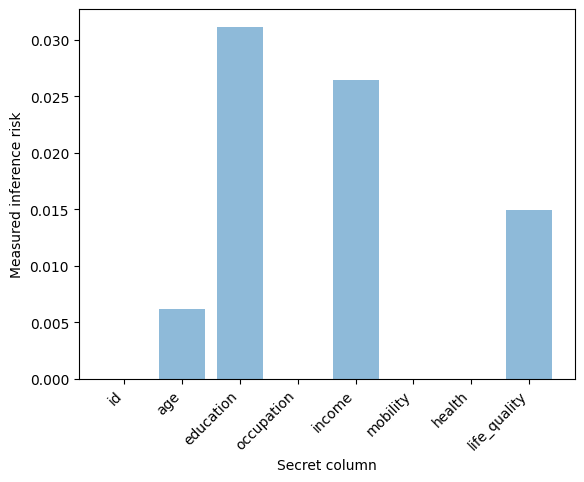

In [26]:
fig, ax = plt.subplots()

risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

ax.bar(x=columns, height=risks, alpha=0.5, ecolor='black', capsize=10)

plt.xticks(rotation=45, ha='right')
# ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_ylabel("Measured inference risk")
_ = ax.set_xlabel("Secret column")